## PYTHON DATA ANALYSIS PROJECT
# Nigeria Incidents Data Analysis Project

PROJECT INTRODUCTION:
This project analyzes incidents, accidents, and violence-related deaths across Nigeria.

The aim is to identify:

1) States with highest incidents
2) States with highest number of deaths.
3) Which incident categories lead to the most deaths.
4) How incidents trend over a given period.

RESEARCH QUESTIONS: 

    1) Top 10 States with the highest number of incidents?
    
    2) Top 10 States with the highest number of deaths?
    
    3) Which incident categories lead to the most deaths?
    
    4) How do incidents trend between June 2023- June 2024 ?
    
    
    


## Data Cleaning
- checked nulls
- split 'Title' column
- fixed 'States'
- Standardize 'Incidents'
- Date corrections
- Removed Duplicates

## Exploratory Data Analysis (EDA)
- State distributions
- Incident categories
- Trend checks

## Visualizations
RQ1–RQ4 charts

## Findings
Key insights from each chart

## Recommendations
Policy/security suggestions.

## 9. Conclusion
Summary

In [1]:
# STEP 2
# DATA PREPARATION AND CLEANING
# IMPORTING THE NECESSARY TOOLS/LIBRARIES.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("personal files/incidents.csv")

In [2]:
# EXAMINE THE FIRST 5 ROWS OF THE DATASET TO UNDERSTAND THE STRUCTURE.

df.head()


,Identifier,Title,Start date,End date,Number of deaths
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1


In [3]:
# EXAMINE THE NUMBER OF ROWS, DATA TYPE, NUMBER OF COLUMNS,EXACT COLUMN NAMES AND LAST FIVE ROWS OF THE DATASET .
df.shape
df.info()
df.columns
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Identifier        7500 non-null   object
 1   Title             7500 non-null   object
 2   Start date        7500 non-null   object
 3   End date          7500 non-null   object
 4   Number of deaths  7500 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 293.1+ KB


,Identifier,Title,Start date,End date,Number of deaths
7495,IBD024354,"Auto Crash, Niger",2022-06-18,2022-06-18,18
7496,IBD024357,"Boat Mishap, Bayelsa",2022-06-18,2022-06-18,7
7497,IBD024385,"Fulani Herdsmen and Youths, Abia",2022-06-18,2022-06-18,3
7498,IBD024352,"Mob vs Phone Thief, Bayelsa",2022-06-18,2022-06-18,1
7499,IBD024344,"Herdsmen Attack, Benue",2022-06-17,2022-06-17,2


In [4]:
# CONVERT START DATE, END DATE COLUMNS TO PROPER DATETIME.

df["Start date"] = pd.to_datetime(df["Start date"], errors="coerce")
df["End date"] = pd.to_datetime(df["End date"], errors="coerce")

In [5]:
# CHECK INVALID START DATE AND END DATE ROWS.

df[df["Start date"].isnull() | df["End date"].isnull()]

,Identifier,Title,Start date,End date,Number of deaths
5842,IBD028043,"Police Kill Kidnapper, Yobe",NaT,NaT,1


In [6]:
# REMOVE INVALID DATE ROWS
df = df.dropna(subset=["Start date", "End date"])

In [7]:
# CHECK DATE LOGIC ERRORS.
# OBSERVED THAT END DATE CAME BEFORE START DATE IN SOME ROWS.

wrong_dates = df[df["End date"] < df["Start date"]]
wrong_dates

,Identifier,Title,Start date,End date,Number of deaths
2136,IBD028052,"Auto Crash, Abia",2024-05-23,2023-05-23,4
2836,IBD029365,"Kidnap Victims, Imo",2024-03-01,2024-02-01,5
3422,IBD028563,"Assailants vs Lady, Lagos",2023-12-01,2023-11-01,1
4084,IBD027910,"Troops Kill kidnappers, Plateau",2023-08-28,2023-08-04,1
4261,IBD027680,"Cult Killing, Lagos",2023-08-01,2023-07-01,1
4709,IBD027203,"Student vs Host Community, Ogun",2023-05-29,2023-05-28,1
7336,IBD024913,"Cult Killing, Lagos",2022-07-07,2022-07-01,2


In [8]:
#FIX START DATE AND END DATE ISSUES AS SEEN ABOVE.


df.loc[df["End date"] < df["Start date"], "End date"] = df["Start date"]


In [9]:
# Check if date logic error was cleaned.

(df["End date"] < df["Start date"]).sum()

np.int64(0)

In [10]:
# SPLIT TITLE COLUMN TO SEPARATE INCIDENT AND STATE.
# Reason: Title Column contains Incident + State

df[["Incident", "State"]] = df["Title"].str.rsplit(",", n=1, expand=True)

In [11]:
df

,Identifier,Title,Start date,End date,Number of deaths,Incident,State
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1,Food Poisoning,Imo
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1,Gunmen Kill Man,Benue
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1,Auto Crash,Lagos
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1,Stray Bullets,Sokoto
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1,Lightening Kills Herder,Kaduna
...,...,...,...,...,...,...,...
7495,IBD024354,"Auto Crash, Niger",2022-06-18,2022-06-18,18,Auto Crash,Niger
7496,IBD024357,"Boat Mishap, Bayelsa",2022-06-18,2022-06-18,7,Boat Mishap,Bayelsa
7497,IBD024385,"Fulani Herdsmen and Youths, Abia",2022-06-18,2022-06-18,3,Fulani Herdsmen and Youths,Abia
7498,IBD024352,"Mob vs Phone Thief, Bayelsa",2022-06-18,2022-06-18,1,Mob vs Phone Thief,Bayelsa


In [12]:
# CHECK HOW MANY ROWS FAILED THE SPLIT ABOVE
failed_split = df[
    df["Incident"].isna() |
    df["State"].isna() |
    (df["Incident"].astype(str).str.strip() == "") |
    (df["State"].astype(str).str.strip() == "")
]

failed_split[["Title", "Incident", "State"]].head(20)


,Title,Incident,State
60,Police vs Kidnappers. Delta,Police vs Kidnappers. Delta,None
78,Police vs Gunmen Benue,Police vs Gunmen Benue,None
171,Gunmen vs Site Engineer Edo,Gunmen vs Site Engineer Edo,None
330,Police vs IPOB/ESN Imo,Police vs IPOB/ESN Imo,None
837,Ritual Killing Delta,Ritual Killing Delta,None
857,"Vigilantes vs Kidnappers,",Vigilantes vs Kidnappers,
858,Youths vs LASTMA/Police,Youths vs LASTMA/Police,None
865,Banditry Katsina,Banditry Katsina,None
1768,Building Collapse FCT (Abuja),Building Collapse FCT (Abuja),None
1800,Vigilantes vs Bandits,Vigilantes vs Bandits,None


In [13]:
# OFFICIAL STATES IN NIGERIA


official_states = [
    "Abia","Adamawa","Akwa Ibom","Anambra","Bauchi","Bayelsa","Benue",
    "Borno","Cross River","Delta","Ebonyi","Edo","Ekiti","Enugu",
    "Gombe","Imo","Jigawa","Kaduna","Kano","Katsina","Kebbi","Kogi",
    "Kwara","Lagos","Nasarawa","Niger","Ogun","Ondo","Osun","Oyo",
    "Plateau","Rivers","Sokoto","Taraba","Yobe","Zamfara","FCT (Abuja)"
]




In [14]:

# SECONDARY SPLIT FOR FAILED STATES

for state in sorted(official_states, key=len, reverse=True):
    mask = (
        df["State"].isna() &
        df["Title"].astype(str).str.endswith(state, na=False)
    )
    
    df.loc[mask, "Incident"] = (
        df.loc[mask, "Title"]
        .str.replace(f"{state}$", "", regex=True)
        .str.strip(" .,-")
    )
    
    df.loc[mask, "State"] = state

In [15]:
# CHECK UNAFFECTED ROWS

unaffected_rows = df[
    df["Incident"].isna() |
    df["State"].isna() |
    df["Title"].astype(str).eq(df["Incident"].astype(str))
]

unaffected_rows[["Title", "Incident", "State"]]

,Title,Incident,State
858,Youths vs LASTMA/Police,Youths vs LASTMA/Police,None
1768,Building Collapse FCT (Abuja),Building Collapse FCT (Abuja),FCT (Abuja)
1800,Vigilantes vs Bandits,Vigilantes vs Bandits,None
2318,Man Shot at Fuel Station,Man Shot at Fuel Station,None
2932,Police vs Bandit,Police vs Bandit,None
5182,Troops vs Bandits,Troops vs Bandits,None
6136,Air Force vs Bandits,Air Force vs Bandits,None


### Split Validation Check
A post-split validation audit was performed on the `Title` column to identify rows where the `Incident` and `State` extraction logic did not fully apply. Rows with missing values, retained state names in the `Incident` field, and titles lacking delimiters were isolated and corrected using secondary rule-based splitting.

In [16]:
# HANDLE REMAINING NO-STATE ROWS

df["State"] = df["State"].fillna("Unknown")

In [17]:
still_failed = df[
    df["State"].isna() |
    (df["State"].astype(str).str.strip() == "")
]

still_failed[["Title", "Incident", "State"]]

,Title,Incident,State
857,"Vigilantes vs Kidnappers,",Vigilantes vs Kidnappers,
6321,"Landlady vs Tenant,",Landlady vs Tenant,
6884,"Police vs Kidnapper,",Police vs Kidnapper,


In [18]:
# fix blank spaces as seeen in the table above
# convert blank string to missing
# assign Unknown

df["State"] = (
    df["State"]
    .replace("", pd.NA)   
    .fillna("Unknown")    
)

In [19]:
# Revalidate Again

still_failed = df[
    df["State"].isna() |
    (df["State"].astype(str).str.strip() == "")
]

still_failed[["Title", "Incident", "State"]]

,Title,Incident,State


In [20]:






df.loc[[857, 6321, 6884], ["Title", "Incident", "State"]]

,Title,Incident,State
857,"Vigilantes vs Kidnappers,",Vigilantes vs Kidnappers,Unknown
6321,"Landlady vs Tenant,",Landlady vs Tenant,Unknown
6884,"Police vs Kidnapper,",Police vs Kidnapper,Unknown


In [21]:
# CLEAN INCIDENT COLUMN
df["Incident"] = df["Incident"].str.strip().str.title()

In [22]:
for state in official_states:
    mask = (
        df["State"].eq(state) &
        df["Incident"].astype(str).str.endswith(state, na=False)
    )
    
    df.loc[mask, "Incident"] = (
        df.loc[mask, "Incident"]
        .str.replace(f"{state}$", "", regex=True)
        .str.strip(" .,-")
    )

In [23]:
df.loc[[1768], ["Title", "Incident", "State"]]

,Title,Incident,State
1768,Building Collapse FCT (Abuja),Building Collapse Fct (Abuja),FCT (Abuja)


In [24]:
df[
    df["Incident"].astype(str).str.contains(
        "ss|ry|ary|\\.|,",
        case=False,
        na=False
    )
][["Incident"]].drop_duplicates().head(50)

,Incident
25,Chieftaincy Tussle
42,Assailants Vs Motorcycle Rider
53,Assailants Vs Security Man
69,Banditary
71,Assailants Vs Security Guard
95,Assailants Vs Bride
120,Auxiliary Nurse
124,Assailant Vs Man
186,Gunmen Vs Businessman
196,Banditry


In [25]:
# Correct wrong spelling

incident_fixes = {
    "Banditary": "Banditry",
    "Bandtiry": "Banditry",
    "Banditsary": "Banditry",
    "Banditsry": "Banditry",
    "Miliatry": "Military",
    "Assaliants": "Assailants",
    " Va ": " Vs ",
    "Dss": "DSS",
    "Auto Crash.": "Auto Crash",
    "Kidnapper": "Kidnappers",
    "Kidnappersss" : "Kidnappers",
    "Army Vs Kidnapperss" : "Army Vs Kidnappers",
    "Police Vs Bandit": "Police Vs Bandits",
    "Troops Vs Bandit": "Troops Vs Bandits",
    "Gunmen Kill": "Gunmen Attack",
    "Auto Crash": "Road Accident",
    "Building Collapse": "Building Collapse",
    "Bussinessman" : "Businessman",
    "Terrorist'S" : "Terrorist",
    "Banditssssss" : "Bandits",
    "Banditss" : "Bandits",
    "Kidnapperss" : "Kidnappers",
    "Nigeriens": "Nigerians",
    "Ndlea": "NDLEA",
    "Governor'S" : "Governor's",
    "Naf" : "NAF",
    "Assembly'S" : "Assembly's",
    "Lecture" : "Lecturer",
    "Brother'S" : "Brother's",
    "Nis" : "NIS",
    "Policemenm" : "Policemen",
    "Lga" : "LGA",
    "Dg" : "DG",
    "Pastor'S" : "Pastor's",
    "Inec" : "INEC",
    "Attacjk" : "Attack",
    "Fct" : " ",
    "/" : "Vs",
    
    
    
    
    
    
}

for wrong, correct in incident_fixes.items():
    df["Incident"] = df["Incident"].str.replace(
        wrong, correct, regex=False
    )

In [26]:
df['Incident'] = df['Incident'].replace([', Fct', 'Fct', ', Ondo'], '', regex=False)

In [27]:
sorted(df["Incident"].dropna().unique())[:100]


['1 Drowns',
 '1 Killed',
 '10 Die In Stampede',
 '2 Die Inside Pit',
 '2 Died',
 '2 Drowns',
 '2 Found Dead',
 '2 Killed',
 '3 Die In Church',
 '3 Died',
 '3 Drown',
 '3 Drowns',
 '3 Killed',
 '3 Men Kill Labourer',
 '3 People Burnt To Death',
 '5 Drown',
 'Abducted Boy',
 'Accidental Discharge',
 'Accountant Kill By Robbers',
 'Air Force Vs Bandits',
 'Air Force Vs Boko Haram',
 'Air Force Vs Iswap',
 'Air Force Vs Terrorists',
 'Airport Security Vs Girl',
 'Alcohol Competition',
 'Amotekun Vs Boy',
 'Amotekun Vs Student',
 'Amotekun Vs Traders',
 'Ansaru Attack',
 'Armed Robber',
 'Armed Robber Vs Mob',
 'Armed Robbers',
 'Armed Robbers Attack',
 'Armed Robbers Kill 1',
 'Armed Robbers Kill One',
 'Armed Robbers Vs Guard',
 'Armed Robbers Vs Man',
 'Armed Robbers Vs Motorcyclist',
 'Armed Robbers Vs Police',
 'Armed Robbers Vs Rider Manager',
 'Armed Robbers Vs Security Guard',
 'Armed Robbers Vs Student',
 'Armed Robbers Vs Uber Driver',
 'Armed Robbers Vs Watchman',
 'Armed Robber

In [28]:
# remove residual punctuations

df["Incident"] = (
    df["Incident"]
    .str.strip(" .,")
    .str.replace(r"\s+", " ", regex=True)
)

In [29]:
df[
    df["Incident"].astype(str).str.contains(
        "Band|Ass|Mili|\\.|Va",
        case=False,
        na=False
    )
][["Incident"]].drop_duplicates().head(100)

,Incident
31,Pipeline Vandal
33,Troops Kill Bandit
42,Assailants Vs Motorcycle Rider
46,Bandits Kill 2
47,Bandits Attack
...,...
1565,Bandit Vs Army
1606,Assailants Vs Motorcyclists
1609,Bandits Kill Man
1644,Soldiers Vs Bandit


In [30]:
df["Incident"].value_counts().head(50)

Incident
Road Accident                     1033
Banditry                           298
Gunmen Attack                      221
Domestic Violence                  162
Police Vs Kidnappers               138
Flooding                           115
Army Vs Bandits                    114
Cult Killing                       113
Cult Clash                         102
Herdsmen Attack                     99
Communal Clash                      91
Ritual Killing                      89
Political Violence                  77
Electrocution                       72
Boat Mishap                         70
Inferno                             68
Building Collapse                   61
Army Vs Boko Haram                  57
Boko Haram Attack                   47
Police Vs Bandits                   43
Flood Disaster                      42
Army Vs Terrorists                  40
Medical Negligence                  40
Assailants Vs Man                   36
Soldiers Vs Bandits                 31
Gunmen Vs Police

In [31]:
print("Unique incidents:", df["Incident"].nunique())
print("Blank incidents:", (df["Incident"].astype(str).str.strip() == "").sum())
print("Fake missing:", df["Incident"].isin(["Nan", "None", ""]).sum())

Unique incidents: 2227
Blank incidents: 0
Fake missing: 0


In [32]:
fake_incident_rows = df[df["Incident"].isin(["Nan", "None", ""])]
fake_incident_rows[["Title", "Incident", "State"]]

,Title,Incident,State


### Incident Category Standardization
A rule-based text normalization step was applied to the `Incident` column to correct spelling inconsistencies, punctuation leftovers, acronym formatting, and minor phrase variations. This ensured semantically identical incident categories were consolidated for accurate frequency analysis.

In [33]:
# CLEAN STATE COLUMN

df['State'].unique()

array([' Imo', ' Benue', ' Lagos', ' Sokoto', ' Kaduna', ' Katsina',
       ' Plateau', ' Abia', ' Delta', ' Ogun', ' Gombe', ' Kogi',
       ' FCT (Abuja)', ' Ondo', ' Rivers (Offshore)', ' Kano', ' Kebbi',
       ' Edo', ' Ekiti', ' Cross River', ' Rivers', ' Anambra', ' Borno',
       ' Enugu', ' Bauchi', ' Osun', ' Zamfara', ' Adamawa', 'Delta',
       ' Yobe', ' Ebonyi', 'Benue', ' Kwara', ' Jigawa', ' Nasarawa',
       ' Akwa Ibom', ' Niger', ' Bayelsa', ' Oyo', 'Edo', ' Zamafara',
       ' Taraba', ' bauchi', ' Cross RIvers', 'Imo', 'Borno', 'Unknown',
       'Katsina', ' Jigiwa', ' FCT', ' Jiagawa', ' Abuja', 'FCT (Abuja)',
       ' delta', ' River', ' katisna', ' kogi', ' Taraba`',
       ' FCT ( Abuja)', ' Anmabra', ' Akwa ibom', 'Akwa Ibom', ' Uyo',
       ' Kadun', ' RIvers', ' Bonny', ' Bayelsa (Offshore)', ' Nasaraawa',
       ' Akwa Ibom (Offshore)', ' Kadauna', ' kwara', ' Katsina 1',
       ' Katsina 2', ' Abuja (FCT)', ' Hamza Musa', ' Nasarwa',
       ' ANambra', ' B

In [34]:
# CLEAN STATE COLUMN
df["State"] = df["State"].astype(str).str.strip().str.title()

In [35]:
# CORRECT WRONG STATE SPELLINGS
state_corrections = {
    # Anambra variations
    "Anmabra": "Anambra",
    "Anambra": "Anambra",

    # Bauchi variations
    "Bauchi": "Bauchi",
    "bauchi": "Bauchi",
    
    # Benue variations
    "Benue": "Benue",
    
    # Borno variations
    "Borno": "Borno",
    "Bornon": "Borno",
    
    # Cross River variations
    "Cross Rivers": "Cross River",
    "Cross Rivers ": "Cross River",
    "Cross RIvers": "Cross River",
    "Cross RIvers ": "Cross River",
    
    # Delta variations
    "Delta": "Delta",
    "delta": "Delta",
    
    # Edo variations
    "Edo": "Edo",
    "Edo ": "Edo",
    
    # Ekiti
    "Ekiti": "Ekiti",
    
    # Enugu
    "Enugu": "Enugu",
    
    # FCT / Abuja variations
    "Fct": "FCT (Abuja)",
    "Abuja": "FCT (Abuja)",
    "(Abuja)": "FCT (Abuja)",
    "Fct(Abuja)": "FCT (Abuja)",
    "Fct (Abuja)": "FCT (Abuja)",
    "Fct ( Abuja)": "FCT (Abuja)",
    "Abuja (Fct)": "FCT (Abuja)",
    "( Abuja)" : "FCT (Abuja)",
    
    # Akwa Ibom variations
    "Akwa Ibom": "Akwa Ibom",
    "Akwa ibom": "Akwa Ibom",
    "Akwa Ibom (Offshore)": "Akwa Ibom",
    "Uyo": "Akwa Ibom",
    
    # Bayelsa variations
    "Bayelsa": "Bayelsa",
    "Bayelsa (Offshore)": "Bayelsa",
    
    # Rivers variations
    "Rivers": "Rivers",
    "River": "Rivers",
    "Rivers (Offshore)": "Rivers",
    "RiVers": "Rivers",
    "Rivers (Offshore)": "Rivers",
    "Rivers (Offshore)": "Rivers",
    
    # Kaduna variations
    "Kaduna": "Kaduna",
    "Kadun": "Kaduna",
    "Kadauna": "Kaduna",
    
    # Katsina variations
    "Katsina": "Katsina",
    "Katisna": "Katsina",
    "Katsina 1": "Katsina",
    "Katsina 2": "Katsina",
    
    # Jigawa variations
    "Jigawa": "Jigawa",
    "Jiagawa": "Jigawa",
    "Jigaawa": "Jigawa",
    "Jigiwa": "Jigawa",
    
    # Nasarawa variations
    "Nasaraawa": "Nasarawa",
    "Nasarwa": "Nasarawa",
    
    # Zamfara variations
    "Zamfara": "Zamfara",
    "Zamafara": "Zamfara",
    
    # Taraba variations
    "Taraba": "Taraba",
    "Taraba`": "Taraba",
    
    # Niger
    "Niger": "Niger",
    "Niger State": "Niger",
    
    # Oyo
    "Oyo": "Oyo",
    
    # Ogun
    "Ogun": "Ogun",
    
    # Plateau
    "Plateau": "Plateau",
    
    # Sokoto
    "Sokoto": "Sokoto",
    
    # Gombe
    "Gombe": "Gombe",
    
    # Kogi
    "Kogi": "Kogi",
    "kogi": "Kogi",
    
    # Kwara
    "Kwara": "Kwara",
    "kwara": "Kwara",
    
    # Abia
    "Abia": "Abia",
    
    # Edo handled above
    
    # Rivers handled above
    
    # Fallback / unknown
    "Hamza Musa": "Unknown",
    "Unknown": "Unknown",
    
    # Port Harcourt maps to Rivers
    "Port Harcourt": "Rivers",
    
    # Bonny (belongs to Rivers)
    "Bonny": "Rivers",
}

In [36]:
df["State"] = df["State"].replace(state_corrections)
df['State'] = df['State'].str.strip().str.title()


In [37]:
df['State'].unique()

array(['Imo', 'Benue', 'Lagos', 'Sokoto', 'Kaduna', 'Katsina', 'Plateau',
       'Abia', 'Delta', 'Ogun', 'Gombe', 'Kogi', 'Fct (Abuja)', 'Ondo',
       'Rivers', 'Kano', 'Kebbi', 'Edo', 'Ekiti', 'Cross River',
       'Anambra', 'Borno', 'Enugu', 'Bauchi', 'Osun', 'Zamfara',
       'Adamawa', 'Yobe', 'Ebonyi', 'Kwara', 'Jigawa', 'Nasarawa',
       'Akwa Ibom', 'Niger', 'Bayelsa', 'Oyo', 'Taraba', 'Unknown'],
      dtype=object)

In [38]:
print(sorted(df['State'].unique()))

['Abia', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa', 'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo', 'Ekiti', 'Enugu', 'Fct (Abuja)', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Unknown', 'Yobe', 'Zamfara']


In [39]:
# check for actual rows with 'Unknown' values
unknown_rows = df[df['State'] == 'Unknown']
print(unknown_rows)

     Identifier                               Title Start date   End date  \
857   IBD031227           Vigilantes vs Kidnappers, 2024-11-13 2024-11-13   
858   IBD031215             Youths vs LASTMA/Police 2024-11-12 2024-11-12   
1800  IBD030215               Vigilantes vs Bandits 2024-07-07 2024-07-07   
2318  IBD029670            Man Shot at Fuel Station 2024-05-01 2024-05-01   
2932  IBD029060                    Police vs Bandit 2024-02-17 2024-02-17   
5182  IBD026720                   Troops vs Bandits 2023-04-01 2023-04-01   
5355  IBD029197  Master Warrant Officer, Hamza Musa 2023-03-10 2023-03-10   
6136  IBD025740                Air Force vs Bandits 2022-11-19 2022-11-19   
6321  IBD025544                 Landlady vs Tenant, 2022-10-28 2022-10-28   
6884  IBD027875                Police vs Kidnapper, 2022-08-28 2022-08-28   

      Number of deaths                  Incident    State  
857                  7  Vigilantes Vs Kidnappers  Unknown  
858                  1  Youths V

In [40]:
df["State"].nunique()

38

In [41]:
df = df[df['State'] != 'Unknown'].copy()

In [42]:
df["State"].nunique()

37

In [43]:
# CREATE TIME FEATURES
df["Year"] = df["Start date"].dt.year
df["Month"] = df["Start date"].dt.month
df["Month Name"] = df["Start date"].dt.month_name()

In [44]:
df

,Identifier,Title,Start date,End date,Number of deaths,Incident,State,Year,Month,Month Name
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1,Food Poisoning,Imo,2025,4,April
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1,Gunmen Attack Man,Benue,2025,3,March
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1,Road Accident,Lagos,2025,3,March
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1,Stray Bullets,Sokoto,2025,3,March
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1,Lightening Kills Herder,Kaduna,2025,3,March
...,...,...,...,...,...,...,...,...,...,...
7495,IBD024354,"Auto Crash, Niger",2022-06-18,2022-06-18,18,Road Accident,Niger,2022,6,June
7496,IBD024357,"Boat Mishap, Bayelsa",2022-06-18,2022-06-18,7,Boat Mishap,Bayelsa,2022,6,June
7497,IBD024385,"Fulani Herdsmen and Youths, Abia",2022-06-18,2022-06-18,3,Fulani Herdsmen And Youths,Abia,2022,6,June
7498,IBD024352,"Mob vs Phone Thief, Bayelsa",2022-06-18,2022-06-18,1,Mob Vs Phone Thief,Bayelsa,2022,6,June


In [45]:
# FINAL DATA QUALITY CHECK

df.info()
df["State"].value_counts().head(20)


<class 'pandas.core.frame.DataFrame'>
Index: 7489 entries, 0 to 7499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Identifier        7489 non-null   object        
 1   Title             7489 non-null   object        
 2   Start date        7489 non-null   datetime64[ns]
 3   End date          7489 non-null   datetime64[ns]
 4   Number of deaths  7489 non-null   int64         
 5   Incident          7489 non-null   object        
 6   State             7489 non-null   object        
 7   Year              7489 non-null   int32         
 8   Month             7489 non-null   int32         
 9   Month Name        7489 non-null   object        
dtypes: datetime64[ns](2), int32(2), int64(1), object(5)
memory usage: 585.1+ KB


State
Lagos          624
Ogun           485
Kaduna         465
Delta          353
Benue          328
Niger          326
Borno          316
Fct (Abuja)    314
Anambra        283
Plateau        269
Rivers         246
Katsina        230
Edo            212
Zamfara        208
Imo            203
Ondo           201
Kwara          191
Bauchi         184
Oyo            176
Kano           172
Name: count, dtype: int64

In [46]:
(df["State"].astype(str).str.strip() == "").sum()

np.int64(0)

In [47]:
df["State"].isin(["Nan", "None", ""]).sum()

np.int64(0)

In [48]:
df["State"].isna().sum()

np.int64(0)

The `State` column was validated using uniqueness checks, frequency distributions, blank-value detection, missing-value inspection, and comparison against an official list of Nigerian states. The final audit confirmed that only valid state categories, Abuja, and an `Unknown` fallback label remained.

In [49]:
# drop 'Title' column
# drop duplicates
df = df.drop(columns=["Title"])
df = df.drop_duplicates()
df.reset_index(drop=True)

,Identifier,Start date,End date,Number of deaths,Incident,State,Year,Month,Month Name
0,IBD031681,2025-04-18,2025-04-18,1,Food Poisoning,Imo,2025,4,April
1,IBD032064,2025-03-31,2025-03-31,1,Gunmen Attack Man,Benue,2025,3,March
2,IBD032058,2025-03-31,2025-03-31,1,Road Accident,Lagos,2025,3,March
3,IBD032066,2025-03-31,2025-03-31,1,Stray Bullets,Sokoto,2025,3,March
4,IBD032062,2025-03-30,2025-03-30,1,Lightening Kills Herder,Kaduna,2025,3,March
...,...,...,...,...,...,...,...,...,...
7469,IBD024354,2022-06-18,2022-06-18,18,Road Accident,Niger,2022,6,June
7470,IBD024357,2022-06-18,2022-06-18,7,Boat Mishap,Bayelsa,2022,6,June
7471,IBD024385,2022-06-18,2022-06-18,3,Fulani Herdsmen And Youths,Abia,2022,6,June
7472,IBD024352,2022-06-18,2022-06-18,1,Mob Vs Phone Thief,Bayelsa,2022,6,June


## Final Dataset Quality Assurance
A complete post-cleaning validation was performed across the full dataset, including data types, missing values, duplicate rows, blank strings, fake missing values, split integrity checks, and random sample inspection. The final audit confirmed that the dataset is fully standardized and ready for exploratory data analysis and dashboard deployment.

In [50]:
df.to_csv("cleaned_incidents.csv", index=False)



In [51]:
# EDA
# BASIC DATA OVERVIEW

In [52]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7474, 9)


,Identifier,Start date,End date,Number of deaths,Incident,State,Year,Month,Month Name
0,IBD031681,2025-04-18,2025-04-18,1,Food Poisoning,Imo,2025,4,April
1,IBD032064,2025-03-31,2025-03-31,1,Gunmen Attack Man,Benue,2025,3,March
2,IBD032058,2025-03-31,2025-03-31,1,Road Accident,Lagos,2025,3,March
3,IBD032066,2025-03-31,2025-03-31,1,Stray Bullets,Sokoto,2025,3,March
4,IBD032062,2025-03-30,2025-03-30,1,Lightening Kills Herder,Kaduna,2025,3,March


RESEARCH QUESTIONS: 

    1) Top 10 States with the highest number of incidents?
    
    2) Top 10 States with the highest number of deaths?
    
    3) Which incident categories lead to the most deaths?
    
    4) How do incidents trend over time?
    
    

In [53]:
# RQ1
# Top 10  states with the highest number of Incident?

top_states = df["State"].value_counts().head(10)
top_states

State
Lagos          624
Ogun           484
Kaduna         463
Delta          352
Benue          328
Niger          326
Borno          315
Fct (Abuja)    314
Anambra        282
Plateau        268
Name: count, dtype: int64

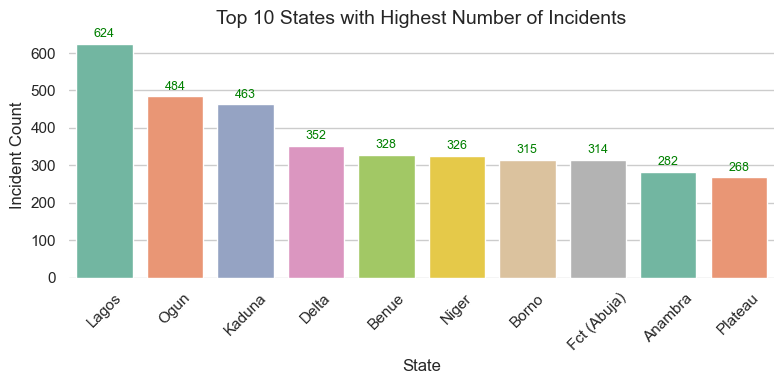

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
top_states = (
    df["State"]
    .value_counts()
    .head(10)
    .reset_index()
)
top_states.columns = ["State", "Incident Count"]



# Initialize the figure
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

# Set palette
palette = sns.color_palette("Set2", n_colors=len(top_states))




# Plot bar chart
ax = sns.barplot(
    data=top_states,
    x="State",
    y="Incident Count",
    hue="State",         
    palette=palette,
    legend=False
)

# Additon of labels properly
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,   # center of the bar
        p.get_height() + 10,           # just above the bar
        int(p.get_height()),           # label value
        ha='center', va='bottom',
        fontsize=9, color="green"
    )

# Axis labels and title
ax.set(
    xlabel="State",
    ylabel="Incident Count"
)

# Clean up spines(Left and bottom chart frame)
sns.despine(left=True, bottom=True)

# Title
plt.title("Top 10 States with Highest Number of Incidents", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
# RSQ 2
# Top 10 States with the highest number of deaths?

top_death_states = (
    df.groupby("State")["Number of deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

In [56]:
top_death_states

,State,Number of deaths
0,Borno,5738
1,Kaduna,2569
2,Zamfara,2546
3,Niger,2468
4,Benue,2101
5,Katsina,2079
6,Plateau,1495
7,Lagos,1056
8,Ogun,977
9,Anambra,899


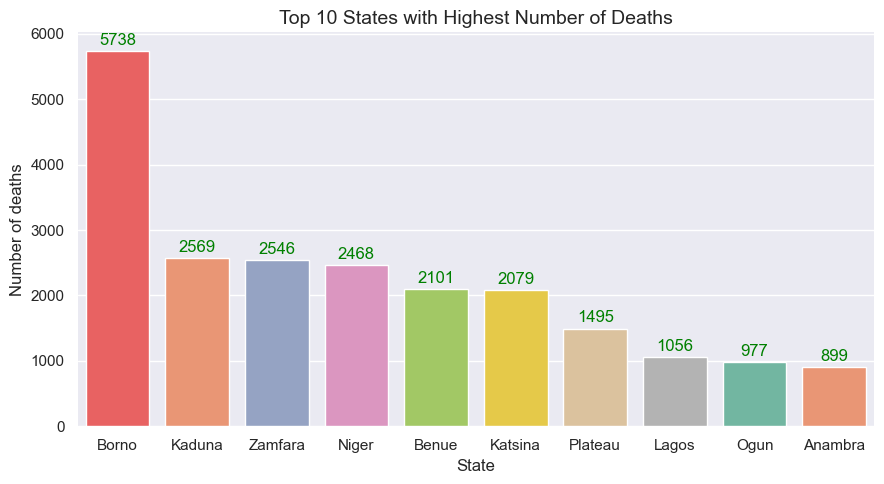

In [57]:

import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
top_death_states = (
    df.groupby("State")["Number of deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)


# Initialize the figure
plt.figure(figsize=(9, 5))
sns.set_theme(style="darkgrid")

# Create a palette with distinct colors
palette = sns.color_palette("Set2", n_colors=len(top_death_states))

# States with the highest deaths
max_idx = top_death_states["Number of deaths"].idxmax()


# Place the state with highest death in red colour.
palette[max_idx] = "#FF4B4B"

# barplot with hue + legend=False
ax = sns.barplot(
    data=top_death_states,
    x="State",
    y="Number of deaths",
    hue="State",        
    palette=palette,
    legend=False          
)

# Add labels to each bar (blue text, light weight)
for index, row in top_death_states.iterrows():
    ax.text(index, row["Number of deaths"] + 50, str(row["Number of deaths"]),
            ha='center', va='bottom', fontsize=12, color="green")

# Axis labels and title
ax.set(
    xlabel="State",
    ylabel="Number of deaths"
)

# Clean up spines
sns.despine(left=True, bottom=True)

# Title
plt.title("Top 10 States with Highest Number of Deaths", fontsize=14)
plt.tight_layout()
plt.show()

In [58]:
# RQ3
# Which incident categories lead to the most deaths?
top_deadly_incidents = (
    df.groupby("Incident")["Number of deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

In [59]:
top_deadly_incidents

,Incident,Number of deaths
0,Road Accident,4533
1,Banditry,2904
2,Army Vs Boko Haram,1197
3,Gunmen Attack,1197
4,Army Vs Bandits,988
5,Herdsmen Attack,985
6,Boat Mishap,972
7,Flooding,713
8,NAF Vs Bandits,666
9,Boko Haram Attack,561


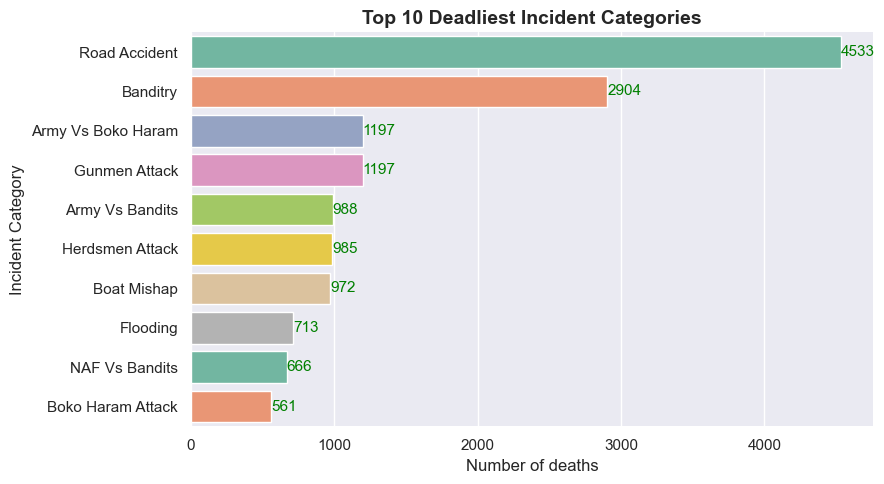

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
top_deadly_incidents = (
    df.groupby("Incident")["Number of deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Initialize the figure
plt.figure(figsize=(9, 5))
sns.set_theme(style="darkgrid")

# barplot
ax = sns.barplot(
    data=top_deadly_incidents,
    x="Number of deaths",
    y="Incident",
    hue="Incident",          
    palette="Set2",          # professional distinct colors
    legend=False             # suppress legend since hue is just for colors
)

# Add blue labels to each bar
for index, row in top_deadly_incidents.iterrows():
    ax.text(row["Number of deaths"] + 0.5, index, str(row["Number of deaths"]),
            va='center', fontsize=11,color="green")

# Axis labels and title
ax.set(
    xlabel="Number of deaths",
    ylabel="Incident Category"
)

# Clean up spines
sns.despine(left=True, bottom=True)

# Title
plt.title("Top 10 Deadliest Incident Categories", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

In [61]:
# RQ4: How do incidents trend between June 2023 and June 2024 ?

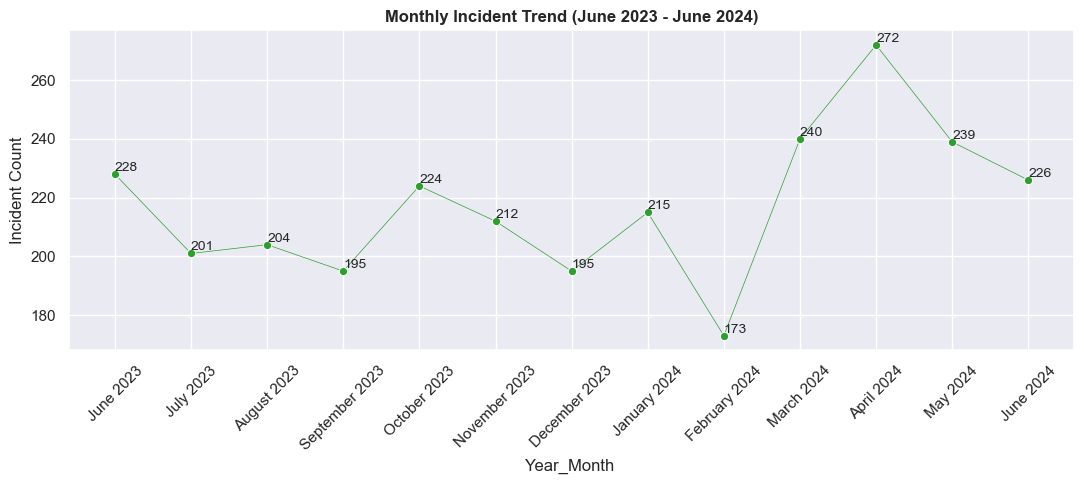

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter June 2023 - June 2024
df_filtered = df[
    ((df['Year'] == 2023) & (df['Month'] >= 6)) |
    ((df['Year'] == 2024) & (df['Month'] <= 6))
]

# Grouping by Year + Month
incident_trend = (
    df_filtered.groupby(["Year", "Month", "Month Name"])
    .size()
    .reset_index(name="Count")
)

# data labels
incident_trend["Month_Label"] = (
    incident_trend["Month Name"] + " " + incident_trend["Year"].astype(str)
)

# Sort
incident_trend = incident_trend.sort_values(["Year", "Month"])

# Identifying peak month
peak_row = incident_trend.loc[incident_trend["Count"].idxmax()]

# Plot
plt.figure(figsize=(11, 5))
sns.set_theme(style="darkgrid")
ax = sns.lineplot(
    data=incident_trend,
    x="Month_Label",
    y="Count",
    marker="o",
    linewidth=0.5,
    color="tab:green"
)

# Add labels to each point
for x, y in zip(incident_trend["Month_Label"], incident_trend["Count"]):
    ax.text(x, y, str(y), ha='left', va='bottom', fontsize=10)


# Titles and labels
plt.title("Monthly Incident Trend (June 2023 - June 2024)", fontsize=12, weight="bold")
plt.xlabel("Year_Month ")
plt.ylabel("Incident Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FINDINGS:

Research Question 1 – Top 10 States with Highest Number of Incidents.  
- Lagos recorded the highest number of incidents (over 600), followed by Ogun and Kaduna (~500 each).  
- Other states like Delta, Benue, Niger, Borno, FCT (Abuja), Anambra, and Plateau had between 300–400 incidents.  
- Lagos clearly stands out as the most incident-prone state.

Research Question 2 – Top 10 States with Highest Number of Deaths  
- Borno had the highest death toll (~6,000), far exceeding other states.  
- Kaduna, Zamfara, Niger, and Benue also recorded several thousand deaths.  
- Lagos, despite leading in incidents, had fewer deaths compared to conflict-heavy states like Borno and Zamfara.  
- This suggests that incident severity varies significantly across states.

Research Question 3 – Incident Categories with Highest Deaths  
- Road accidents accounted for the highest number of deaths, surpassing conflict-related categories.  
- Banditry, Army vs Boko Haram, and Gunmen Attacks also contributed heavily to fatalities.  
- Natural disasters (like flooding) and other categories (boat mishaps, herdsmen attacks) had lower but notable death counts.  
- Everyday hazards (road accidents) proved deadlier overall than armed conflict.

Research Question 4 – Incident Trends between June 2023-June 2024 
- Between June 2023 and June 2024, incidents showed a fluctuating but overall rising trend
- Incidents were fairly stable in mid‑2023, dipped at the end of the year, hit their lowest in February 2024, then surged to a peak in April before moderating again by June 2024.




Conclusion
The analysis reveals that while Lagos experiences the highest number of incidents, Borno suffers the greatest fatalities, highlighting differences in incident severity. Road accidents emerge as the single deadliest category, underscoring the importance of everyday safety measures alongside conflict resolution. Between june 2023-June 2024,incidents were fairly stable. In mid‑2023, dipped at the end of the year, hit their lowest in February 2024, then surged to a peak in April before moderating again by June 2024.

Recommendations
1. Targeted Interventions:  
   - Focus safety and prevention programs in Lagos to reduce incident frequency.  
   - Prioritize conflict resolution and humanitarian aid in Borno, Zamfara, and Kaduna to reduce fatalities.

2. Road Safety Campaigns:  
   - Strengthen traffic regulations, road infrastructure, and public awareness campaigns to address the high death toll from road accidents.  

3. Incident Monitoring:  
   - Establish real-time monitoring systems to detect and respond to spikes in incidents, especially during high-risk months.  

4. Policy Integration:  
   - Combine security measures with public health and disaster management strategies to address both conflict-related and non-conflict incidents.